<a href="https://colab.research.google.com/github/rahulsharma-crtl/AI_image_detector/blob/main/MiniPro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install diffusers accelerate torchmetrics scikit-learn matplotlib tqdm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.0 MB/s eta 0:00:00


In [ ]:
import os
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

from diffusers import DDIMScheduler, DDPMPipeline
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import tqdm


@dataclass
class Config:
    model_id: str = "google/ddpm-cifar10-32"
    image_size: int = 32

    # Better but still okay for Colab T4
    num_real_images: int = 500
    num_fake_images: int = 500

    # More steps = better DIRE, but slower
    dire_steps: int = 50

    batch_size: int = 32
    dire_batch_size: int = 16

    classifier_epochs: int = 25
    learning_rate: float = 8e-4
    seed: int = 42
    artifact_dir: str = "dire_artifacts"


cfg = Config()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if device != "cuda":
    print("Warning: This will be slow. Use Colab T4 GPU.")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)
os.makedirs(cfg.artifact_dir, exist_ok=True)


Device: cuda


In [ ]:
dtype = torch.float16 if device == "cuda" else torch.float32

pipe = DDPMPipeline.from_pretrained(
    cfg.model_id,
    torch_dtype=dtype,
    use_safetensors=False
).to(device)

pipe.set_progress_bar_config(disable=True)

unet = pipe.unet.eval()

ddim_scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
ddim_scheduler.set_timesteps(cfg.dire_steps, device=device)

print("Loaded diffusion model:", cfg.model_id)



Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded diffusion model: google/ddpm-cifar10-32


In [ ]:
to_tensor_32 = T.Compose([
    T.Resize((cfg.image_size, cfg.image_size)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

to_pil = T.Compose([
    T.Normalize([-1.0, -1.0, -1.0], [2.0, 2.0, 2.0]),
    T.Lambda(lambda x: x.clamp(0, 1)),
    T.ToPILImage(),
])


def show_grid(images, title, max_images=16):
    if torch.is_tensor(images):
        shown = images[:max_images].detach().cpu()
        shown = (shown + 1.0) / 2.0
        grid = torchvision.utils.make_grid(shown, nrow=4).permute(1, 2, 0).numpy()
    else:
        tensors = torch.stack([to_tensor_32(img) for img in images[:max_images]])
        shown = (tensors + 1.0) / 2.0
        grid = torchvision.utils.make_grid(shown, nrow=4).permute(1, 2, 0).numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(grid)
    plt.title(title)
    plt.axis("off")
    plt.show()


def load_real_cifar_images(count):
    dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=to_tensor_32,
    )

    indices = list(range(len(dataset)))
    random.shuffle(indices)

    selected = indices[:count]
    images = torch.stack([dataset[i][0] for i in selected])

    return images


@torch.no_grad()
def generate_fake_images(count, batch_size):
    fake_batches = []
    remaining = count

    while remaining > 0:
        current_batch = min(batch_size, remaining)

        result = pipe(
            batch_size=current_batch,
            generator=torch.Generator(device=device).manual_seed(cfg.seed + remaining),
        )

        batch = torch.stack([to_tensor_32(img) for img in result.images])
        fake_batches.append(batch)

        remaining -= current_batch

    return torch.cat(fake_batches, dim=0)


In [ ]:
@torch.no_grad()
def compute_dire_batch(images):
    """
    Input: images in [-1, 1], shape [B, 3, 32, 32]
    Output: DIRE maps in [0, 1], shape [B, 3, 32, 32]
    """

    images = images.to(device=device, dtype=dtype)
    sample = images.clone()

    timesteps = ddim_scheduler.timesteps

    # Correct DDIM inversion:
    # image -> noisy sample
    for index, timestep in enumerate(timesteps.flip(0)):
        model_output = unet(sample, timestep).sample
        alpha_t = ddim_scheduler.alphas_cumprod[timestep]

        pred_original = (
            sample - torch.sqrt(1 - alpha_t) * model_output
        ) / torch.sqrt(alpha_t)

        if index == len(timesteps) - 1:
            noisy_sample = sample
            break

        next_timestep = timesteps.flip(0)[index + 1]
        alpha_next = ddim_scheduler.alphas_cumprod[next_timestep]

        sample = (
            torch.sqrt(alpha_next) * pred_original
            + torch.sqrt(1 - alpha_next) * model_output
        )

    # Correct DDIM reconstruction:
    # noisy sample -> reconstructed image
    reconstructed = noisy_sample

    for timestep in timesteps:
        model_output = unet(reconstructed, timestep).sample

        reconstructed = ddim_scheduler.step(
            model_output,
            timestep,
            reconstructed,
            eta=0.0,
            return_dict=False,
        )[0]

    dire = torch.abs(images - reconstructed).float()

    flat = dire.flatten(start_dim=1)
    min_val = flat.min(dim=1).values.view(-1, 1, 1, 1)
    max_val = flat.max(dim=1).values.view(-1, 1, 1, 1)

    dire = (dire - min_val) / (max_val - min_val + 1e-8)

    return dire.cpu()


def compute_dire_dataset(images, batch_size):
    maps = []
    loader = DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=False)

    for (batch,) in tqdm(loader, desc="Computing DIRE maps"):
        maps.append(compute_dire_batch(batch))

    return torch.cat(maps, dim=0)


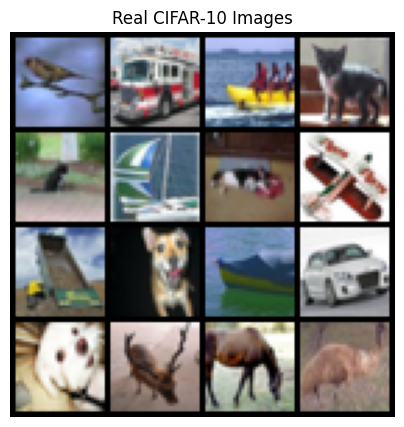

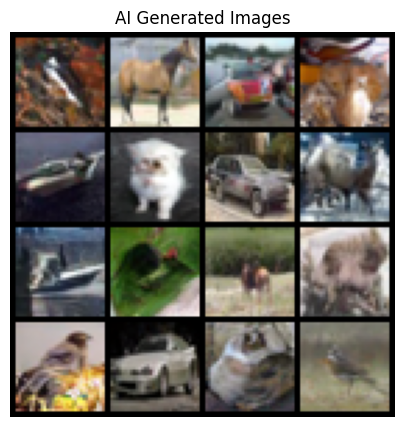

Dataset shape: torch.Size([1000, 3, 32, 32])
Labels: 0 = real, 1 = synthetic


In [ ]:
real_images = load_real_cifar_images(cfg.num_real_images)
fake_images = generate_fake_images(cfg.num_fake_images, cfg.batch_size)

show_grid(real_images, "Real CIFAR-10 Images")
show_grid(fake_images, "AI Generated Images")

all_images = torch.cat([real_images, fake_images], dim=0)

labels = torch.cat([
    torch.zeros(len(real_images), dtype=torch.long),
    torch.ones(len(fake_images), dtype=torch.long),
])

print("Dataset shape:", all_images.shape)
print("Labels: 0 = real, 1 = synthetic")


Computing DIRE maps:   0%|          | 0/63 [00:00<?, ?it/s]

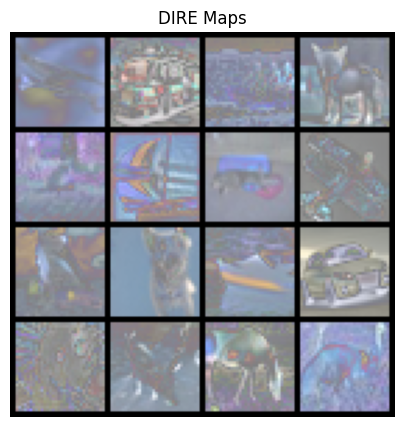

Combined feature shape: torch.Size([1000, 6, 32, 32])
Saved improved DIRE dataset.


In [ ]:
dire_maps = compute_dire_dataset(all_images, cfg.dire_batch_size)

show_grid(dire_maps, "DIRE Maps")

# Better feature: original image + DIRE map = 6 channels
combined_features = torch.cat([all_images, dire_maps], dim=1)

torch.save(
    {
        "images": all_images,
        "dire_maps": dire_maps,
        "combined_features": combined_features,
        "labels": labels,
    },
    os.path.join(cfg.artifact_dir, "dire_dataset_better.pt"),
)

print("Combined feature shape:", combined_features.shape)
print("Saved improved DIRE dataset.")


In [ ]:
class DIREClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        # 6 channels: RGB image + DIRE map
        self.features = nn.Sequential(
            nn.Conv2d(6, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [ ]:
dataset = TensorDataset(combined_features, labels)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(cfg.seed),
)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

model = DIREClassifier().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.learning_rate,
    weight_decay=1e-4,
)

criterion = nn.CrossEntropyLoss()

best_acc = 0.0

for epoch in range(1, cfg.classifier_epochs + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    preds = []
    truth = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu()

            preds.extend(pred.tolist())
            truth.extend(y.tolist())

    acc = accuracy_score(truth, preds)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), os.path.join(cfg.artifact_dir, "best_dire_classifier.pt"))

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Accuracy: {acc:.4f} | "
        f"Best: {best_acc:.4f}"
    )

model.load_state_dict(torch.load(os.path.join(cfg.artifact_dir, "best_dire_classifier.pt")))
print("Loaded best model.")


Epoch 01 | Train Loss: 0.6704 | Test Accuracy: 0.4300 | Best: 0.4300
Epoch 02 | Train Loss: 0.6311 | Test Accuracy: 0.6150 | Best: 0.6150
Epoch 03 | Train Loss: 0.6202 | Test Accuracy: 0.5400 | Best: 0.6150
Epoch 04 | Train Loss: 0.6139 | Test Accuracy: 0.6700 | Best: 0.6700
Epoch 05 | Train Loss: 0.5766 | Test Accuracy: 0.6700 | Best: 0.6700
Epoch 06 | Train Loss: 0.5209 | Test Accuracy: 0.4700 | Best: 0.6700
Epoch 07 | Train Loss: 0.5870 | Test Accuracy: 0.5900 | Best: 0.6700
Epoch 08 | Train Loss: 0.5749 | Test Accuracy: 0.5700 | Best: 0.6700
Epoch 09 | Train Loss: 0.5106 | Test Accuracy: 0.6400 | Best: 0.6700
Epoch 10 | Train Loss: 0.5082 | Test Accuracy: 0.6100 | Best: 0.6700
Epoch 11 | Train Loss: 0.5117 | Test Accuracy: 0.6400 | Best: 0.6700
Epoch 12 | Train Loss: 0.4810 | Test Accuracy: 0.6700 | Best: 0.6700
Epoch 13 | Train Loss: 0.4627 | Test Accuracy: 0.6200 | Best: 0.6700
Epoch 14 | Train Loss: 0.4210 | Test Accuracy: 0.6400 | Best: 0.6700
Epoch 15 | Train Loss: 0.4313 | Te

In [ ]:
model.eval()

preds = []
truth = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        logits = model(x)
        pred = logits.argmax(dim=1).cpu()

        preds.extend(pred.tolist())
        truth.extend(y.tolist())

print("Confusion Matrix:")
print(confusion_matrix(truth, preds))

print("\nClassification Report:")
print(classification_report(
    truth,
    preds,
    target_names=["real", "synthetic"]
))


Confusion Matrix:
[[64 23]
 [42 71]]

Classification Report:
              precision    recall  f1-score   support

        real       0.60      0.74      0.66        87
   synthetic       0.76      0.63      0.69       113

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.67       200
weighted avg       0.69      0.68      0.68       200



Predicted label: synthetic
Real probability: 0.0137
Synthetic probability: 0.9863


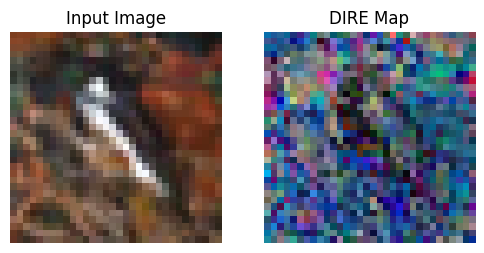

In [ ]:
@torch.no_grad()
def predict_image(pil_image):
    image_tensor = to_tensor_32(pil_image).unsqueeze(0)

    dire_map = compute_dire_batch(image_tensor)

    combined = torch.cat([image_tensor, dire_map], dim=1)

    model.eval()

    logits = model(combined.to(device))
    probabilities = F.softmax(logits, dim=1)[0].cpu()

    result = {
        "real_probability": float(probabilities[0]),
        "synthetic_probability": float(probabilities[1]),
        "predicted_label": "synthetic" if probabilities[1] > probabilities[0] else "real",
        "dire_map": dire_map[0],
    }

    return result


sample_image = to_pil(fake_images[0])

result = predict_image(sample_image)

print("Predicted label:", result["predicted_label"])
print("Real probability:", round(result["real_probability"], 4))
print("Synthetic probability:", round(result["synthetic_probability"], 4))

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result["dire_map"].permute(1, 2, 0).numpy())
plt.title("DIRE Map")
plt.axis("off")

plt.show()


Saving img.jpeg to img.jpeg
Predicted label: real
Real probability: 0.9982
Synthetic probability: 0.0018


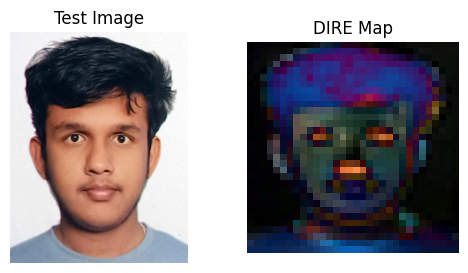

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]
test_image = Image.open(image_path).convert("RGB")

result = predict_image(test_image)

print("Predicted label:", result["predicted_label"])
print("Real probability:", round(result["real_probability"], 4))
print("Synthetic probability:", round(result["synthetic_probability"], 4))

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.title("Test Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result["dire_map"].permute(1, 2, 0).numpy())
plt.title("DIRE Map")
plt.axis("off")

plt.show()

SyntaxError: invalid syntax (420992690.py, line 3)